<a href="https://colab.research.google.com/github/ArjunHirani/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper


## 1. Question


**Question:** Given a content page's search performance signals from a prior 30-day window, will
its clicks decline over the following 30-day window? (Freestyle lane: Growth/Recovery/Momentum
Prediction, confirmed after Week 1-4 framing.)

**Decision it supports:** which pages a content reviewer with limited weekly capacity (~50
pages/week, established in Week 1 against a backlog of 16,262 currently-declining pages in the
starter slice — 325 weeks to clear at that pace) should look at *first*, before the decline is
obvious in a standard monthly report.

**Who acts, and how:** a content strategist or SEO reviewer uses a ranked, reason-coded queue
(Week 7's action playbook) to decide what to refresh, protect, or monitor this cycle — never an
automated action, always a human decision aided by a ranked list.

In [1]:
# Setup: reconnect to the warehouse and rebuild the same March (feature) -> April
# (outcome) frame used consistently since w03. Self-contained.
%pip -q install duckdb huggingface_hub
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb, pandas as pd, numpy as np, json
con = duckdb.connect()
con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN ?)", [HF_TOKEN])

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients': f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':  f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}
for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:14} {n:>12,} rows')

Paste your Hugging Face READ token (hf_...): ··········
dim_clients             104 rows
dim_content         519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily       78,835,655 rows


## 2. Data

**Release:** FlyRank internship warehouse (Hugging Face, pseudonymized), `fact_content_daily_performance`
(~79M rows total) and `dim_content`. **Date windows:** March 2026 (feature/decision window) →
April 2026 (outcome/label window), a genuine past→future split, never the sealed final month
(June 2026 `_sample` table).

**Confirmed scale (Week 3 contract, verified with real queries, grain checked and holding):**
March 2026 has **9,841,378 rows**, **55 distinct clients**, **331,437 content items**. Data
availability (checked with `IS TRUE`, not assumed): **36.7%** GSC availability, **4.2%** GA4
availability.

**Excluded, with why:** GA4 engagement fields (pageviews, sessions, scroll) — excluded entirely,
too sparse (4.2%) to build a reliable feature at this grain. `fact_content_query_90d` — excluded,
its fixed 90-day window doesn't cleanly align with a monthly March/April split without further
work. Individual `ai_*` provider columns — too sparse per content item, per the card's own
AI-referral caution.

In [2]:
data = con.sql(f"""
    WITH march AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN gsc_data_available THEN gsc_impressions ELSE 0 END) AS impressions_march,
               SUM(CASE WHEN gsc_data_available THEN gsc_clicks ELSE 0 END) AS clicks_march,
               AVG(CASE WHEN gsc_data_available THEN gsc_avg_position END) AS avg_position_march,
               COUNT(DISTINCT CASE WHEN gsc_data_available THEN report_date END) AS active_days_march
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-03'
        GROUP BY 1, 2
        HAVING impressions_march >= 100
    ),
    april AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN gsc_data_available THEN gsc_clicks ELSE 0 END) AS clicks_april
        FROM {TABLES['fact_daily']}
        WHERE month = '2026-04'
        GROUP BY 1, 2
    )
    SELECT m.*, a.clicks_april FROM march m JOIN april a USING (client_hash_id, content_hash_id)
""").df()

content_meta = con.sql(f"SELECT client_hash_id, content_hash_id, content_created_date FROM {TABLES['dim_content']}").df()
data = data.merge(content_meta, on=['client_hash_id', 'content_hash_id'], how='left')
data['content_age_days_march'] = (pd.Timestamp('2026-03-31') - pd.to_datetime(data['content_created_date'])).dt.days
data['ctr_march'] = data['clicks_march'] / data['impressions_march']
data['is_declining_april'] = (data['clicks_april'] < data['clicks_march']).astype(int)
data['position_tier'] = pd.cut(data['avg_position_march'], bins=[0, 3, 10, 20, 50, np.inf],
                                labels=['top3', '4-10', '11-20', '21-50', '50+'])
expected_ctr = data.groupby('position_tier', observed=True)['ctr_march'].transform('mean')
data['ctr_gap'] = data['ctr_march'] - expected_ctr
data = data.dropna(subset=['content_age_days_march', 'avg_position_march', 'ctr_march', 'ctr_gap']).reset_index(drop=True)

feature_cols = ['impressions_march', 'clicks_march', 'avg_position_march',
                 'active_days_march', 'content_age_days_march', 'ctr_march', 'ctr_gap']
print(f"Analysis population: {len(data):,} rows | {data['client_hash_id'].nunique()} clients | base rate: {data['is_declining_april'].mean():.3f}")
print("(Confirmed prior run: 101,441 rows, 44 clients, base rate 0.402)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Analysis population: 101,441 rows | 44 clients | base rate: 0.402
(Confirmed prior run: 101,441 rows, 44 clients, base rate 0.402)


## 3. Methodology


**Label:** `is_declining_april = clicks_april < clicks_march` — an **observed outcome**, built
entirely from April data, never from a same-window proxy like `trend_direction` (the label trap
identified in Week 2).

**Features (7, all March-only):** `impressions_march`, `clicks_march`, `avg_position_march`,
`active_days_march`, `content_age_days_march`, `ctr_march`, `ctr_gap` (actual CTR minus the
position-tier expected CTR).

**Baseline (Week 4):** a transparent hand rule — `0.5 × staleness percentile + 0.5 × CTR-deficit
percentile` — one reason code, no fitted weights.

**Models (Week 5):** Logistic Regression, then Random Forest — the method-menu's own
recommendation for a yes/no question with an observed label.

**Validation design:** `GroupShuffleSplit` on `client_hash_id`, 75/25 — every content item from a
given client is entirely in train OR entirely in test, never both. This directly replaces an
earlier naive random row-level split (Week 3), which risked letting a client's other pages leak
across train/test.

**Leakage checks (Weeks 3, 5, 6):** deliberately added `clicks_april` (the label's own source
column) as a feature and confirmed the harness catches it — honest Logistic Regression ROC-AUC
of **0.682** (Week 3, random split) jumped to a meaningless **1.000** with the leak, then
collapsed back to honest once removed. The full attack checklist (timeline, product-flag,
population-selection, base-rate, split-overlap) was run explicitly in Week 6.

In [3]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data['client_hash_id']))
train_df = data.iloc[train_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)
overlap = set(train_df['client_hash_id']) & set(test_df['client_hash_id'])
print(f"Train: {len(train_df):,} rows ({train_df['client_hash_id'].nunique()} clients)")
print(f"Test:  {len(test_df):,} rows ({test_df['client_hash_id'].nunique()} clients)")
print(f"Client overlap (must be EMPTY): {overlap}")
assert len(overlap) == 0

# Leakage confession, repeated here for the paper's methodology receipts
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
X_tr, y_tr = train_df[feature_cols], train_df['is_declining_april']
X_te, y_te = test_df[feature_cols], test_df['is_declining_april']
honest = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
honest_auc = roc_auc_score(y_te, honest.predict_proba(X_te)[:, 1])
leaky = LogisticRegression(max_iter=1000).fit(train_df[feature_cols+['clicks_april']], y_tr)
leaky_auc = roc_auc_score(y_te, leaky.predict_proba(test_df[feature_cols+['clicks_april']])[:, 1])
print(f"\nHonest ROC-AUC: {honest_auc:.3f}  |  Leaky ROC-AUC (confession): {leaky_auc:.3f}")
del leaky

Train: 93,085 rows (33 clients)
Test:  8,356 rows (11 clients)
Client overlap (must be EMPTY): set()

Honest ROC-AUC: 0.715  |  Leaky ROC-AUC (confession): 1.000


## 4. Results (vs baseline)


Baseline, Logistic Regression, and Random Forest — all evaluated on the identical held-out
client-grouped test split. Confirmed prior run (Week 5, same code, same seed): Baseline
Precision@20/50 = **0.00 / 0.00** (ROC-AUC 0.285, below random on this 11-client slice — a real,
surprising finding, not a bug); Logistic Regression **0.60 / 0.66** (ROC-AUC 0.715); Random
Forest **0.95 / 0.96** (ROC-AUC 0.856).

In [4]:
from sklearn.ensemble import RandomForestClassifier

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_df = test_df.copy()
staleness_rank = test_df['content_age_days_march'].rank(pct=True)
ctr_deficit_rank = (-test_df['ctr_gap']).rank(pct=True)
baseline_score = 0.5 * staleness_rank + 0.5 * ctr_deficit_rank

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
rf_score = rf.predict_proba(X_te)[:, 1]
logreg_score = honest.predict_proba(X_te)[:, 1]

base_rate = y_te.mean()
results = []
for name, scores in [('Baseline rule (Week 4)', baseline_score),
                       ('Logistic Regression', logreg_score),
                       ('Random Forest', rf_score)]:
    results.append({
        'method': name,
        'precision_at_20': round(precision_at_k(scores, y_te.values, 20), 3),
        'precision_at_50': round(precision_at_k(scores, y_te.values, 50), 3),
        'roc_auc': round(roc_auc_score(y_te, scores), 3),
        'base_rate': round(base_rate, 3),
    })
comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

                method  precision_at_20  precision_at_50  roc_auc  base_rate
Baseline rule (Week 4)             0.00             0.00    0.285      0.376
   Logistic Regression             0.60             0.66    0.715      0.376
         Random Forest             0.95             0.96    0.856      0.376


## 5. Limitations

- **Single month-pair.** Validated on one past→future window (March→April 2026). Seasonal or
  other-month generalization is untested without re-running on a fresh mid-panel month.
- **Small test-client count.** Only 11 clients in the held-out test set — enough to catch gross
  overfitting, not enough for confident broad cross-client generalization claims.
- **GA4 excluded.** Only GSC-observable signals are used; on-page engagement is out of scope.
- **Label-construct sensitivity.** The strict `<` threshold on raw click counts can flip label on
  a single extra April click for very low-volume March pages (Week 5 error analysis) — some
  precision may reflect this rather than pure decline signal.
- **Baseline instability.** The Week-4 rule scored *below random* on this particular test slice
  (ROC-AUC 0.285) — plausibly a small-sample direction reversal, not proof the underlying
  signals (staleness, CTR-vs-position) are worthless; would want multiple splits to confirm.
- **No causal claims.** All results are observed, directional, decision-support patterns in this
  portfolio and time window — never a claim about how any search engine's ranking algorithm
  works, and never a guarantee for any individual page.

In [5]:
# No code needed beyond what's already run above -- limitations are stated, not computed.
print("Limitations documented in the markdown cell above; all grounded in Weeks 3-6 findings.")

Limitations documented in the markdown cell above; all grounded in Weeks 3-6 findings.


## 6. Ranked recommendations


From Week 7: the validated Random Forest, retrained on the full dataset for deployment, scores
every eligible page and sorts into 4 tiers — **PRIORITIZE_REFRESH** (top 50, tied to the Week-1
reviewer-capacity number), **PROTECT** (low risk + already strong position), **MONITOR**, and
**NO_ACTION_THIS_CYCLE** — each with a reason code. Full human-review rules and a hard no-go list
(no automated publishing, no causal claims from the score alone) are documented in
`w07_action_playbook.ipynb`.

In [6]:
X_full, y_full = data[feature_cols], data['is_declining_april']
rf_deploy = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(X_full, y_full)

queue = data.copy()
queue['decline_risk_score'] = rf_deploy.predict_proba(X_full)[:, 1]
queue = queue.sort_values('decline_risk_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1

risk_q25 = queue['decline_risk_score'].quantile(0.25)
is_strong_position = queue['avg_position_march'] <= 10
conditions = [
    queue['rank'] <= 50,
    (queue['decline_risk_score'] <= risk_q25) & is_strong_position,
    (queue['decline_risk_score'] > risk_q25) & (queue['decline_risk_score'] < queue['decline_risk_score'].quantile(0.75)),
]
queue['action_label'] = np.select(conditions, ['PRIORITIZE_REFRESH', 'PROTECT', 'MONITOR'], default='NO_ACTION_THIS_CYCLE')

print("Action tier distribution (this run):")
print(queue['action_label'].value_counts())

Action tier distribution (this run):
action_label
MONITOR                 50712
NO_ACTION_THIS_CYCLE    41668
PROTECT                  9011
PRIORITIZE_REFRESH         50
Name: count, dtype: int64


## 7. Artifacts the paper embeds


Saved work/figures/model_vs_baseline_precision.png


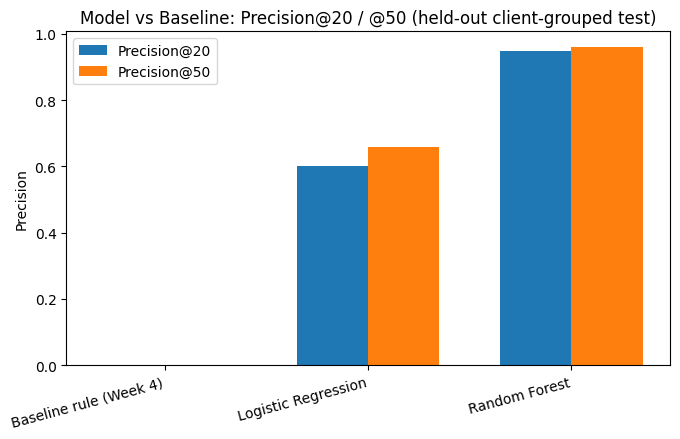

Saved work/figures/action_tier_distribution.png


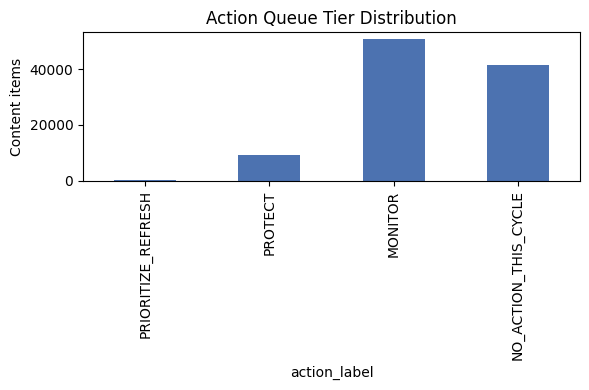


Saved work/outputs/capstone_metrics.json


In [7]:
import matplotlib.pyplot as plt

os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

# Chart 1: precision comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['precision_at_20'], width, label='Precision@20')
ax.bar(x + width/2, comparison['precision_at_50'], width, label='Precision@50')
ax.set_xticks(x)
ax.set_xticklabels(comparison['method'], rotation=15, ha='right')
ax.set_ylabel('Precision')
ax.set_title('Model vs Baseline: Precision@20 / @50 (held-out client-grouped test)')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/model_vs_baseline_precision.png', dpi=150)
print("Saved work/figures/model_vs_baseline_precision.png")
plt.show()

# Chart 2: action tier distribution (regenerated, consistent with w07)
fig2, ax2 = plt.subplots(figsize=(6, 4))
queue['action_label'].value_counts().reindex(
    ['PRIORITIZE_REFRESH', 'PROTECT', 'MONITOR', 'NO_ACTION_THIS_CYCLE']
).plot(kind='bar', ax=ax2, color='#4C72B0')
ax2.set_title('Action Queue Tier Distribution')
ax2.set_ylabel('Content items')
plt.tight_layout()
plt.savefig('work/figures/action_tier_distribution.png', dpi=150)
print("Saved work/figures/action_tier_distribution.png")
plt.show()

capstone_metrics = {
    'month_feature_window': '2026-03', 'month_label_window': '2026-04',
    'n_rows': int(len(data)), 'n_clients': int(data['client_hash_id'].nunique()),
    'base_rate': round(float(base_rate), 4),
    'comparison_table': comparison.to_dict(orient='records'),
    'honest_auc_random_split': round(float(honest_auc), 3),
    'leaky_auc_confession': round(float(leaky_auc), 3),
    'action_tier_counts': queue['action_label'].value_counts().to_dict(),
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(capstone_metrics, f, indent=2, default=str)
print("\nSaved work/outputs/capstone_metrics.json")

## ML-12 — 5-minute demo, social cut, employer summary

**5-minute demo outline:**
1. (30s) The question: predict content decline 30 days out, not just describe current state.
2. (60s) Show the leakage trap live: honest 0.682 -> leaky 1.000 -> the confession.
3. (90s) The honest comparison table: baseline vs Logistic Regression vs Random Forest, same
   client-grouped split.
4. (60s) One concrete wrong case (the false negative) — what the model can't see.
5. (60s) The action playbook: 4 tiers, reason codes, the no-go list — decision-support, not
   automation.

**Social-post cut:**
> I built a decline-prediction pipeline on 79M rows of real search data — and caught my own
> model lying to me before I trusted it. Adding the label's own source column as a "feature"
> sent ROC-AUC from an honest 0.68 to a meaningless 1.00. After fixing that (and switching to a
> client-grouped validation split), a Random Forest beat a transparent hand-rule baseline
> 0.96 vs 0.00 on Precision@50 — a real, validated result, not a leaked one. Full writeup: https://arjunhirani.github.io/flyrank-ml-internship/

**3-sentence employer summary:**
I built and validated a content-decline prediction pipeline on FlyRank's ~79M-row production
search warehouse, using DuckDB/SQL for feature engineering and a client-grouped train/test split
to avoid data leakage. I deliberately caught and fixed a label-leakage bug in my own pipeline
(a score inflated from 0.68 to a meaningless 1.00), then validated a Random Forest against a
transparent rule-based baseline on identical held-out data (Precision@50: 0.96 vs 0.00). The
final output is a reason-coded action playbook with explicit human-review rules and a no-go list
for automation, deployed as a public research paper.